Original file was `fermi_kagome_finite_scan_Vrsv.py`.

In [1]:
import sys
import logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
from E9_fn import util
import E9_fn.E9_models as E9M
import E9_fn.thermodynamics as thmdy
from projects.flat_band_cooling import equilibrium_finder as eqfind
from projects.flat_band_cooling import helper_fns as hpfn

logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


In [2]:
lattice_str = "kagome"
lattice_len = 20
sys_len = 12
# Working from high to low entropy is easier
s_avg = np.hstack((np.linspace(0.51, 0.24, 10), np.linspace(0.22, 0.12, 21)))
V_rsv_offsets = np.linspace(-3.5, 2, 56)#np.linspace(-2., 2., 11)
l_res = 0
V_std_random = 0.
tnnn = 0.
nu_sys = 5/12
nu_rsv = 10/12
runnum_to_load = 1

In [3]:
# initial guesses at the first value of total entropy for each offset
T_guesses = np.array([1. for _ in V_rsv_offsets])
mu_guesses = np.array([2. + V for V in V_rsv_offsets])
N_tol = 1e-3            # Tolerable error in resultant N
S_tol = 1e-1            # Tolerable error in resultant S

In [4]:
parent_folder_name = lattice_str
data_folder = Path(E9path, "projects", "flat_band_cooling", "eigvals_library", parent_folder_name)
param_dict = dict()
if V_std_random != 0:
    param_dict["Vran"] = V_std_random
if tnnn != 0 and lattice_str in {"kagome_nnn", "bilayer_kagome"}:
    param_dict["tnnn"] = tnnn
if l_res != 0:
    param_dict["lres"] = l_res

In [5]:
lattice_dim = (lattice_len, lattice_len)
n_orbs_tot = lattice_len**2 * 3
n_orbs_sys = sys_len**2 * 3
n_orbs_rsv = n_orbs_tot - n_orbs_sys
N_tot = int(nu_sys * n_orbs_sys + nu_rsv * n_orbs_rsv)
N_offsets = len(V_rsv_offsets)
S_total = s_avg * N_tot    # Working from high to low entropy is easier
N_S = len(S_total)

In [6]:
all_T_F = np.zeros(N_offsets)                   # Fermi temperature
all_T = np.full((N_offsets, N_S), np.nan)
all_mu = np.full((N_offsets, N_S), np.nan)
all_E = np.full((N_offsets, N_S), np.nan)
all_S = np.full((N_offsets, N_S), np.nan)
all_N = np.full((N_offsets, N_S), np.nan)
all_nu_sys = np.full((N_offsets, N_S), np.nan)
all_fails = np.zeros((N_offsets, N_S))

for i_rsv, V_rsv in enumerate(V_rsv_offsets):
    logging.debug(f"working on offset = {V_rsv:.4f}...")
    folder_name = hpfn.get_model_str(lattice_str, lattice_dim, sys_len, V_rsv, runnum = runnum_to_load, param_dict = param_dict)
    with open(Path(data_folder, folder_name, "np_arrays.npz"), 'rb') as f:
        loaded_arrs_dict = np.load(f)
        eigvals = loaded_arrs_dict["eigvals"]
        density_sys = loaded_arrs_dict["density_sys"]
    E_range = (eigvals[0], eigvals[-1])
    all_T_F[i_rsv] = eigvals[N_tot - 1] - eigvals[0]

    sp_name = "fermi1"
    name_sr1 = sp_name
    sr_list = [E9M.muVT_subregion(name_sr1, sp_name, n_orbs_tot, +1, None, E_range, [], eigvals)]

    bool_first_bad_S = True
    bad_S_log_fn = logging.warning  # All S smaller than the one that fails will also fail, so surpress the logging level
    for i_S, S_tar in enumerate(S_total):
        # Update guess values, and find the new equilibrium states
        if i_S == 0:
            T_guess_now = T_guesses[i_rsv]
            mu_guess_now = mu_guesses[i_rsv]
        else:
            T_guess_now, mu_guess_now = all_T[i_rsv, i_S - 1], all_mu[i_rsv, i_S - 1]
        Tmu_out, orst = eqfind.muVT_from_NVS_solver(S_tar,
                                                    N_tot,
                                                    sr_list,
                                                    T_guess_now,
                                                    mu_guess_now,
                                                    Tbounds = (0, 2),
                                                    mubounds = (-3, 6),
                                                    options_dict = {"fatol": 1e-8, "xatol": 1e-8})
        T_now, mu_now = Tmu_out[0], Tmu_out[1]
        
        # Double check that the solution is within the specified tolerance
        E_now = thmdy.find_E(eigvals, T_now, mu_now, +1)
        N_now = thmdy.find_Np(eigvals, T_now, mu_now, +1)
        S_now = thmdy.find_S(eigvals, T_now, N_now, +1, mu_now, E_now)
        N_err, S_err = N_now - N_tot, S_now - S_tar
        if orst.success:
            if abs(N_err) < N_tol and abs(S_err) < S_tol:
                all_T[i_rsv, i_S] = T_now
                all_mu[i_rsv, i_S] = mu_now
                all_E[i_rsv, i_S] = E_now
                all_N[i_rsv, i_S] = N_now
                all_S[i_rsv, i_S] = S_now
                all_nu_sys[i_rsv, i_S] = np.sum(util.fermi_stat(eigvals, T_now, mu_now) * density_sys) / n_orbs_sys
            else:
                bad_S_log_fn(f"The solution of V_rsv = {V_rsv:.4f} and S = {S_tar:.4f} doesn't satisfy the specified tolerance!")
                bad_S_log_fn(f"(N_err = {N_err:.4f}, S_err = {S_err:.4f})")
                bad_S_log_fn = logging.debug
                bool_first_bad_S = False
                all_fails[i_rsv, i_S] = 1.
        else:
            bad_S_log_fn(f"The solver failed to converge for V_rsv = {V_rsv:.4f} and S = {S_tar:.4f}!")
            bad_S_log_fn = logging.debug
            bool_first_bad_S = False
            all_fails[i_rsv, i_S] = 1.
all_TTF = all_T / all_T_F[:, np.newaxis]

C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\E9_fn\thermodynamics.py:150: RuntimeWarning: overflow encountered in exp
  return (E_total - mu * Np) / T + xi * np.log(1 + xi * np.exp((mu - E_orbs) / T)).sum()
C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\E9_fn\util.py:681: RuntimeWarning: overflow encountered in exp
  output = 1/(np.exp((E - mu) / tau) + xi)


Text(0.5, 0.98, 'kagome, lattice size (20, 20), system size 12x12 ($\\nu_{sys} =$0.417, $\\nu_{rsv} =$0.833), \n; N_atoms = 820, V_std_random = 0.000')

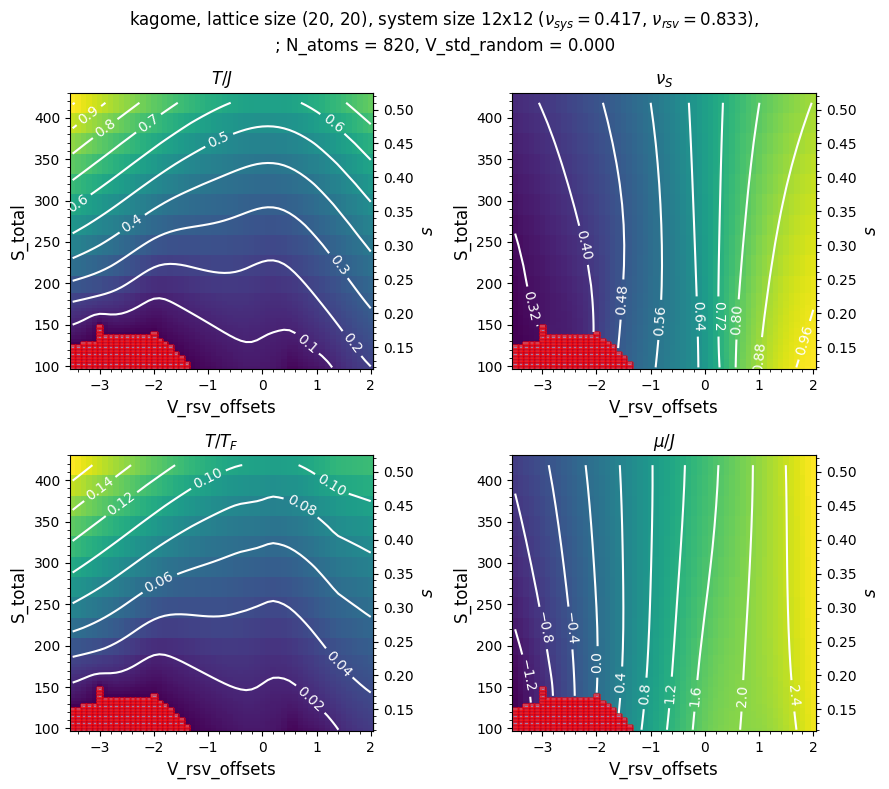

In [7]:
util.set_custom_plot_style(overwrite = {"font.size": 10})

fig_VS = plt.figure(figsize = (9, 8))
ax_T = fig_VS.add_subplot(221)
ax_nu = fig_VS.add_subplot(222)
ax_TTF = fig_VS.add_subplot(223)
ax_mu = fig_VS.add_subplot(224)

for ttl, data, ax in zip([r"$T/J$", r"$\nu_{S}$",   r"$T/T_F$", r"$\mu/J$"],
                         [all_T,    all_nu_sys,     all_TTF,    all_mu],
                         [ax_T,     ax_nu,          ax_TTF,     ax_mu]):
    mesh_T = ax.pcolormesh(V_rsv_offsets, S_total, data.T, shading = 'auto', cmap = 'viridis')
    ax.pcolormesh(V_rsv_offsets, S_total, np.ones_like(all_fails.T), shading = 'auto'
                  , color = "red", alpha = all_fails.T * 0.5, edgecolors = 'none')

    # Add colorbar, labels
    # fig_VS.colorbar(mesh_T, ax = ax, label = f'{ttl} value')
    ax.set_xlabel('V_rsv_offsets')
    ax.set_ylabel('S_total')
    ax.set_title(ttl)
    cntr = ax.contour(V_rsv_offsets, S_total, data.T, colors = "white", linestyles = "solid", levels = 10)
    ax.clabel(cntr, inline = True)

    # right y-axis
    ryax = ax.secondary_yaxis('right', functions = (lambda x: x / N_tot, lambda x: x * N_tot))
    ryax.set_ylabel(r"$s$")
fig_VS.suptitle((f"{lattice_str}, lattice size {lattice_dim}, system size {sys_len}x{sys_len}"
                 " (" r"$\nu_{sys} =$" f"{nu_sys:.3f}, "r"$\nu_{rsv} =$" f"{nu_rsv:.3f}), \n"
                 f"; N_atoms = {N_tot}, V_std_random = {V_std_random:.3f}"))

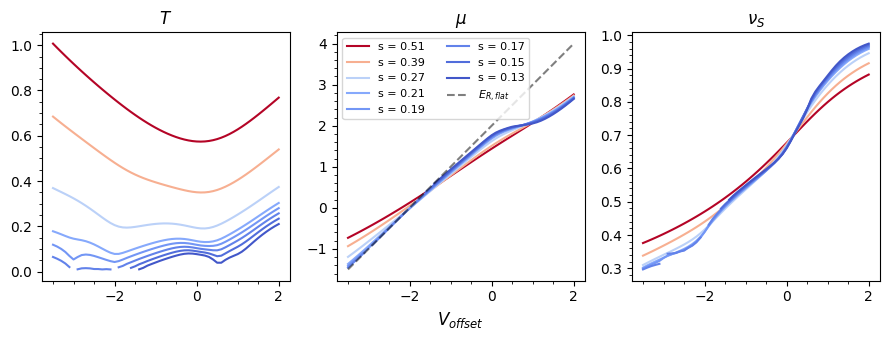

In [26]:
ind_Sselect = np.array([i for i in range(0, N_S, 4)])
ind_ref = np.where(np.round(V_rsv_offsets, 4) == 0.)[0]

fig_S = plt.figure(figsize = (9, 3.5))
ax_T_Sselect = fig_S.add_subplot(131)
ax_mu_Sselect = fig_S.add_subplot(132)
ax_nuS_Sselect = fig_S.add_subplot(133)
cmap = plt.get_cmap('coolwarm')

for i in ind_Sselect:
    s_plt = s_avg[i]
    color = util.get_color(s_plt, s_avg, cmap, assignment = "value")
    # failed_this_S = all_fails[:, i].astype(bool)
    ax_T_Sselect.plot(V_rsv_offsets, all_T[:, i], color = color)
    ax_nuS_Sselect.plot(V_rsv_offsets, all_nu_sys[:, i], color = color)
    ax_mu_Sselect.plot(V_rsv_offsets, all_mu[:, i], color = color, label = f"s = {s_plt:.2f}")
    # ax_T_Sselect.scatter(V_rsv_offsets[failed_this_S], np.nan_to_num(all_T)[failed_this_S, i], color = color, marker = ".")
ax_T_Sselect.set_title(r"$T$")
ax_mu_Sselect.plot(V_rsv_offsets, V_rsv_offsets + 2, label = r"$E_{R, flat}$",
                   color = "black", linestyle = "--", alpha = 0.5)
ax_mu_Sselect.set_title(r"$\mu$")
ax_mu_Sselect.legend(ncols = 2, fontsize = 8)
ax_mu_Sselect.set_xlabel(r"$V_{offset}$")
ax_nuS_Sselect.set_title(r"$\nu_S$")
fig_S.tight_layout()

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\flatband")
file_full_path = Path(thesis_fig_path, "finite_tb_EoS_scan_Voffset.pdf")
fig_S.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches='tight')